
### What was installed:
- **MuJoCo 3.3.6** - The physics engine
- **Gymnasium with MuJoCo support** - RL environment framework

### System Information:
- **OS**: Linux (Ubuntu 5.15.0-140-generic)
- **Architecture**: x86_64
- **Python**: 3.11.10

### Available MuJoCo Environments:
- `Ant-v4`, `Ant-v5`
- `HalfCheetah-v4`, `HalfCheetah-v5`
- `Hopper-v4`, `Hopper-v5`
- `Humanoid-v4`, `Humanoid-v5`
- `HumanoidStandup-v4`, `HumanoidStandup-v5`
- `InvertedDoublePendulum-v4`, `InvertedDoublePendulum-v5`
- `InvertedPendulum-v4`, `InvertedPendulum-v5`
- `Pusher-v4`, `Pusher-v5`
- `Reacher-v4`, `Reacher-v5`
- `Swimmer-v4`, `Swimmer-v5`
- `Walker2d-v4`, `Walker2d-v5`

In [1]:
%%capture
!unset LD_PRELOAD
import os
os.environ.pop('LD_PRELOAD', None)

In [2]:
!python --version

Python 3.11.10


In [3]:
import platform
import sys

print(f"Operating System: {platform.system()}")
print(f"OS Release: {platform.release()}")
print(f"OS Version: {platform.version()}")
print(f"Machine: {platform.machine()}")
print(f"Processor: {platform.processor()}")
print(f"Python Version: {sys.version}")

Operating System: Linux
OS Release: 5.15.0-140-generic
OS Version: #150-Ubuntu SMP Sat Apr 12 06:00:09 UTC 2025
Machine: x86_64
Processor: x86_64
Python Version: 3.11.10 | packaged by conda-forge | (main, Sep 30 2024, 18:08:57) [GCC 13.3.0]


# MuJoCo Installation and Setup

The Jupyter server is running on **Linux (Ubuntu)** with x86_64 architecture. We'll install MuJoCo and its dependencies.

In [4]:
%%bash 
pip install uv
conda install -c conda-forge mesalib
uv pip install mujoco
uv pip install gymnasium[mujoco]
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa

Channels:
 - conda-forge
Platform: linux-64
Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done
Solving environment: ...working... done




==> WARNING: A newer version of conda exists. <==
    current version: 24.9.1
    latest version: 25.9.1

Please update conda by running

==> WARNING: A newer version of conda exists. <==
    current version: 24.9.1
    latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



    $ conda update -n base -c conda-forge conda





# All requested packages already installed.

# All requested packages already installed.



Using Python 3.11.10 environment at: /opt/conda
Audited 1 package in 21ms
Audited 1 package in 21ms
Using Python 3.11.10 environment at: /opt/conda
Audited 1 package in 12ms
Using Python 3.11.10 environment at: /opt/conda
Audited 1 package in 12ms


In [5]:
import os
import mujoco
os.environ['MUJOCO_GL'] = 'osmesa'
os.environ['PYOPENGL_PLATFORM'] = 'osmesa'

print(f"MuJoCo version: {mujoco.__version__}")
print("MuJoCo successfully installed and imported!")

MuJoCo version: 3.3.6
MuJoCo successfully installed and imported!


Environment created: <TimeLimit<OrderEnforcing<PassiveEnvChecker<HopperEnv<Hopper-v5>>>>>
Action space: Box(-1.0, 1.0, (3,), float32)
Observation space: Box(-inf, inf, (11,), float64)

Initial observation shape: (11,)
Step executed successfully!
Reward: 0.9485507722207611

✓ MuJoCo is working correctly!

✓ MuJoCo is working correctly!


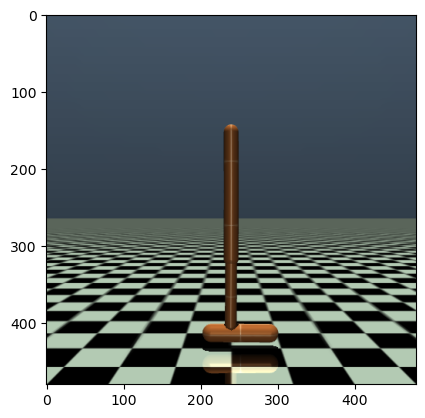

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
# Create a simple MuJoCo environment
env = gym.make('Hopper-v5', render_mode='rgb_array')

print(f"Environment created: {env}")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")

# Reset environment and take a random action
obs, info = env.reset()
print(f"\nInitial observation shape: {obs.shape}")

action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print("Step executed successfully!")
print(f"Reward: {reward}")
frame = env.render()
env.close()
print("\n✓ MuJoCo is working correctly!")

plt.imshow(frame)

## Generate Video from 100 Episode Trajectories

Collect frames from 100 episodes and create a video montage showing the environment in action.

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import os

# Set rendering backend
os.environ['MUJOCO_GL'] = 'osmesa'
os.environ['PYOPENGL_PLATFORM'] = 'osmesa'

# Run 100 episodes and collect frames
num_episodes = 100
all_frames = []
episode_stats = []

print(f"Running {num_episodes} episodes and collecting frames...")

env = gym.make('Hopper-v5', render_mode='rgb_array')

for episode in range(num_episodes):
    obs, info = env.reset()
    episode_frames = []
    total_reward = 0
    steps = 0
    
    # Run episode (max 200 steps per episode to keep video reasonable)
    for step in range(200):
        # Render current frame
        frame = env.render()
        episode_frames.append(frame)
        
        # Take random action
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        
        total_reward += reward
        steps += 1
        
        if terminated or truncated:
            break
    
    # Store stats
    episode_stats.append({
        'episode': episode + 1,
        'steps': steps,
        'reward': total_reward,
        'num_frames': len(episode_frames)
    })
    
    # Add episode frames to collection (sample every 2nd frame to reduce size)
    all_frames.extend(episode_frames[::2])
    
    if (episode + 1) % 10 == 0:
        print(f"  Completed {episode + 1}/{num_episodes} episodes - "
              f"Last episode: {steps} steps, reward: {total_reward:.2f}")

env.close()

print("\n✓ Collection complete!")
print(f"  Total frames collected: {len(all_frames)}")
print(f"  Average episode length: {np.mean([s['steps'] for s in episode_stats]):.1f} steps")
print(f"  Average episode reward: {np.mean([s['reward'] for s in episode_stats]):.2f}")

Running 100 episodes and collecting frames...
  Completed 10/100 episodes - Last episode: 16 steps, reward: 9.37
  Completed 20/100 episodes - Last episode: 32 steps, reward: 21.36
  Completed 30/100 episodes - Last episode: 12 steps, reward: 9.49
  Completed 40/100 episodes - Last episode: 12 steps, reward: 9.98
  Completed 50/100 episodes - Last episode: 13 steps, reward: 6.34
  Completed 60/100 episodes - Last episode: 16 steps, reward: 10.24
  Completed 70/100 episodes - Last episode: 13 steps, reward: 9.46
  Completed 80/100 episodes - Last episode: 15 steps, reward: 12.91
  Completed 90/100 episodes - Last episode: 27 steps, reward: 29.44
  Completed 100/100 episodes - Last episode: 23 steps, reward: 8.29

✓ Collection complete!
  Total frames collected: 1154
  Average episode length: 22.6 steps
  Average episode reward: 17.41


In [ ]:
# Create video animation from all collected frames
print("Creating video animation...")

fig, ax = plt.subplots(figsize=(12, 9))
ax.axis('off')

# Display first frame
img = ax.imshow(all_frames[0])

# Add text for frame counter
frame_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                     fontsize=14, color='white', weight='bold',
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

def animate(i):
    img.set_array(all_frames[i])
    # Calculate which episode we're in
    frames_so_far = 0
    current_episode = 0
    for ep_stat in episode_stats:
        frames_in_ep = ep_stat['num_frames'] // 2  # We sampled every 2nd frame
        if frames_so_far + frames_in_ep > i:
            current_episode = ep_stat['episode']
            break
        frames_so_far += frames_in_ep
    
    frame_text.set_text(f'Frame {i+1}/{len(all_frames)} | Episode ~{current_episode}/{num_episodes}')
    return [img, frame_text]

# Create animation (use smaller interval for smoother playback)
anim = animation.FuncAnimation(
    fig, animate, frames=len(all_frames),
    interval=50, blit=True, repeat=True
)

plt.close()

# Convert to HTML5 video and display
print("Rendering video (this may take a minute)...")
video_html = HTML(anim.to_html5_video())
display(video_html)

print("\n✓ Video created successfully!")
print(f"  Total frames: {len(all_frames)}")
print(f"  Duration: ~{len(all_frames) * 0.05:.1f} seconds at 20 FPS")

Creating video animation...
Rendering video (this may take a minute)...



✓ Video created successfully!
  Total frames: 1154
  Duration: ~57.7 seconds at 20 FPS


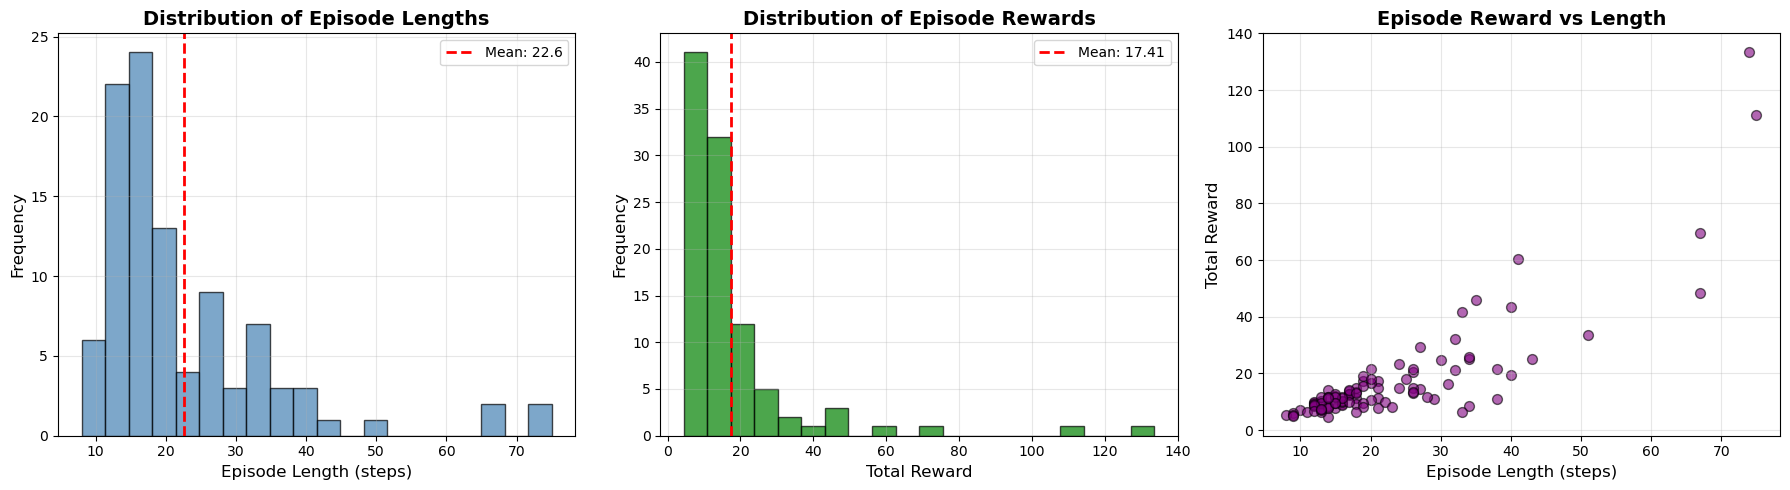


📊 Statistics Summary:
  Episodes: 100
  Avg Length: 22.6 ± 13.2 steps
  Avg Reward: 17.41 ± 18.76
  Max Reward: 133.56
  Min Reward: 4.48


In [9]:
# Visualize episode statistics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Episode lengths
axes[0].hist([s['steps'] for s in episode_stats], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean([s['steps'] for s in episode_stats]), color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {np.mean([s['steps'] for s in episode_stats]):.1f}")
axes[0].set_xlabel('Episode Length (steps)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Episode Lengths', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Episode rewards
axes[1].hist([s['reward'] for s in episode_stats], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean([s['reward'] for s in episode_stats]), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {np.mean([s['reward'] for s in episode_stats]):.2f}")
axes[1].set_xlabel('Total Reward', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Episode Rewards', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Reward vs Length scatter
axes[2].scatter([s['steps'] for s in episode_stats], 
                [s['reward'] for s in episode_stats],
                alpha=0.6, s=50, c='purple', edgecolors='black')
axes[2].set_xlabel('Episode Length (steps)', fontsize=12)
axes[2].set_ylabel('Total Reward', fontsize=12)
axes[2].set_title('Episode Reward vs Length', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Statistics Summary:")
print(f"  Episodes: {num_episodes}")
print(f"  Avg Length: {np.mean([s['steps'] for s in episode_stats]):.1f} ± {np.std([s['steps'] for s in episode_stats]):.1f} steps")
print(f"  Avg Reward: {np.mean([s['reward'] for s in episode_stats]):.2f} ± {np.std([s['reward'] for s in episode_stats]):.2f}")
print(f"  Max Reward: {max([s['reward'] for s in episode_stats]):.2f}")
print(f"  Min Reward: {min([s['reward'] for s in episode_stats]):.2f}")